# Lab 2: Creating an Analytical Base Table (ABT)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
RAW_DATA_DIR = Path("../data/raw")
PROCESSED_DATA_DIR = Path("../data/processed")
FIGURES_DIR = Path("../figures")

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
for file in RAW_DATA_DIR.glob("*.csv"):
    print(file.name)

olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [6]:
customers = pd.read_csv(RAW_DATA_DIR / "olist_customers_dataset.csv")
geolocation = pd.read_csv(RAW_DATA_DIR / "olist_geolocation_dataset.csv")
orders = pd.read_csv(RAW_DATA_DIR / "olist_orders_dataset.csv")
order_items = pd.read_csv(RAW_DATA_DIR / "olist_order_items_dataset.csv")
payments = pd.read_csv(RAW_DATA_DIR / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(RAW_DATA_DIR / "olist_order_reviews_dataset.csv")
products = pd.read_csv(RAW_DATA_DIR / "olist_products_dataset.csv")
sellers = pd.read_csv(RAW_DATA_DIR / "olist_sellers_dataset.csv")
category_translation = pd.read_csv(
    RAW_DATA_DIR / "product_category_name_translation.csv"
)

In [7]:
tables = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "category_translation": category_translation,
}

for name, df in tables.items():
    print(f"{name}: {df.shape}")

customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
products: (32951, 9)
sellers: (3095, 4)
geolocation: (1000163, 5)
category_translation: (71, 2)


In [8]:
for name, df in tables.items():
    print("=" * 60)
    print(name.upper())
    print("=" * 60)
    print(df.head())
    print("\n")

CUSTOMERS
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  


ORDERS
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186

In [9]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"]
)

reviews["review_answer_timestamp"] = pd.to_datetime(
    reviews["review_answer_timestamp"]
)

order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"]
)

In [10]:
orders["purchase_year"] = orders["order_purchase_timestamp"].dt.year
orders["purchase_month"] = orders["order_purchase_timestamp"].dt.month
orders["purchase_day"] = orders["order_purchase_timestamp"].dt.day
orders["purchase_dayofweek"] = orders["order_purchase_timestamp"].dt.day_name()

orders[
    [
        "purchase_year",
        "purchase_month",
        "purchase_day",
        "purchase_dayofweek",
    ]
].head()

,purchase_year,purchase_month,purchase_day,purchase_dayofweek
0,2017,10,2,Monday
1,2018,7,24,Tuesday
2,2018,8,8,Wednesday
3,2017,11,18,Saturday
4,2018,2,13,Tuesday


In [11]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

orders["delivery_delay"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days

orders["is_late_delivery"] = (
    orders["delivery_delay"] > 0
).astype(int)

orders[
    [
        "delivery_days",
        "delivery_delay",
        "is_late_delivery",
    ]
].head()

,delivery_days,delivery_delay,is_late_delivery
0,8.0,-8.0,0
1,13.0,-6.0,0
2,9.0,-18.0,0
3,13.0,-13.0,0
4,2.0,-10.0,0


In [12]:
payments_abt = (
    payments
    .groupby("order_id")
    .agg(
        total_payment=("payment_value", "sum"),
        max_installments=("payment_installments", "max"),
        payment_type=("payment_type", lambda x: x.mode().iloc[0])
    )
    .reset_index()
)

payments_abt.head()

,order_id,total_payment,max_installments,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card


In [13]:
items_abt = (
    order_items
    .groupby("order_id")
    .agg(
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum"),
        total_items=("order_item_id", "count"),
        unique_products=("product_id", "nunique"),
        unique_sellers=("seller_id", "nunique")
    )
    .reset_index()
)

items_abt.head()

,order_id,total_price,total_freight,total_items,unique_products,unique_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1,1,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1,1,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1,1,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1,1,1


In [14]:
reviews_abt = (
    reviews
    .groupby("order_id")
    .agg(
        review_score=("review_score", "mean"),
        has_review_comment=(
            "review_comment_message",
            lambda x: x.notna().any()
        )
    )
    .reset_index()
)

reviews_abt["has_review_comment"] = (
    reviews_abt["has_review_comment"]
    .astype(int)
)

reviews_abt.head()

,order_id,review_score,has_review_comment
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1
1,00018f77f2f0320c557190d7a144bdd3,4.0,0
2,000229ec398224ef6ca0657da4fc703e,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,4.0,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1


In [15]:
# Start with orders
abt = orders.copy()

# Merge customer information
abt = abt.merge(
    customers,
    on="customer_id",
    how="left"
)

# Merge payment features
abt = abt.merge(
    payments_abt,
    on="order_id",
    how="left"
)

# Merge review features
abt = abt.merge(
    reviews_abt,
    on="order_id",
    how="left"
)

# Merge order item features
abt = abt.merge(
    items_abt,
    on="order_id",
    how="left"
)

print(abt.shape)
abt.head()

(99441, 29)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,purchase_day,purchase_dayofweek,delivery_days,delivery_delay,is_late_delivery,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment,max_installments,payment_type,review_score,has_review_comment,total_price,total_freight,total_items,unique_products,unique_sellers
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2,Monday,8.0,-8.0,0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,1.0,voucher,4.0,1.0,29.99,8.72,1.0,1.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,24,Tuesday,13.0,-6.0,0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1.0,boleto,4.0,1.0,118.70,22.76,1.0,1.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,8,Wednesday,9.0,-18.0,0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,3.0,credit_card,5.0,0.0,159.90,19.22,1.0,1.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,18,Saturday,13.0,-13.0,0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,1.0,credit_card,5.0,1.0,45.00,27.20,1.0,1.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,13,Tuesday,2.0,-10.0,0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,1.0,credit_card,5.0,0.0,19.90,8.72,1.0,1.0,1.0


In [16]:
missing = (
    abt.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

order_delivered_customer_date    2965
delivery_days                    2965
delivery_delay                   2965
order_delivered_carrier_date     1783
total_items                       775
unique_sellers                    775
unique_products                   775
total_price                       775
total_freight                     775
has_review_comment                768
review_score                      768
order_approved_at                 160
max_installments                    1
payment_type                        1
total_payment                       1
dtype: int64

In [17]:
summary = pd.DataFrame({
    "Rows": [abt.shape[0]],
    "Columns": [abt.shape[1]],
    "Missing Values": [abt.isnull().sum().sum()],
    "Duplicate Rows": [abt.duplicated().sum()]
})

summary

,Rows,Columns,Missing Values,Duplicate Rows
0,99441,29,16252,0


In [18]:
abt.to_csv(
    PROCESSED_DATA_DIR / "olist_orders_abt.csv",
    index=False
)

summary.to_csv(
    PROCESSED_DATA_DIR / "abt_summary.csv",
    index=False
)

print("ABT saved successfully!")

ABT saved successfully!


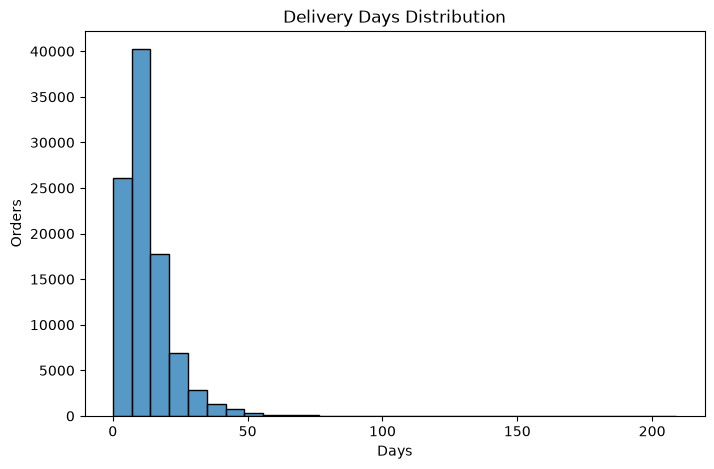

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    abt["delivery_days"].dropna(),
    bins=30
)

plt.title("Delivery Days Distribution")
plt.xlabel("Days")
plt.ylabel("Orders")

plt.savefig(
    FIGURES_DIR / "delivery_days_distribution.png"
)

plt.show()

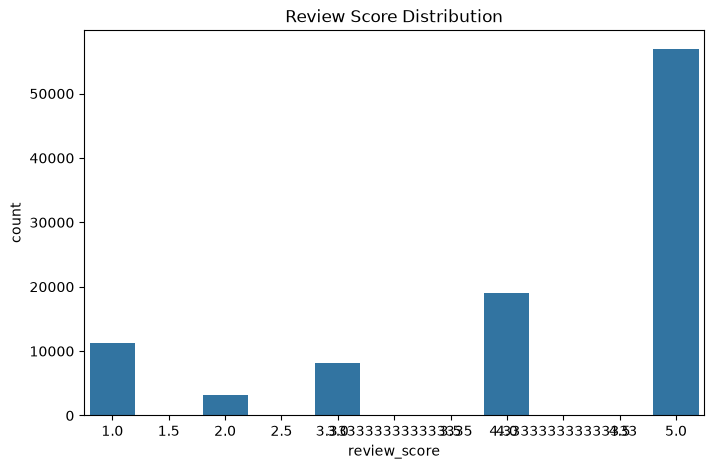

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="review_score",
    data=abt
)

plt.title("Review Score Distribution")

plt.savefig(
    FIGURES_DIR / "review_score_distribution.png"
)

plt.show()

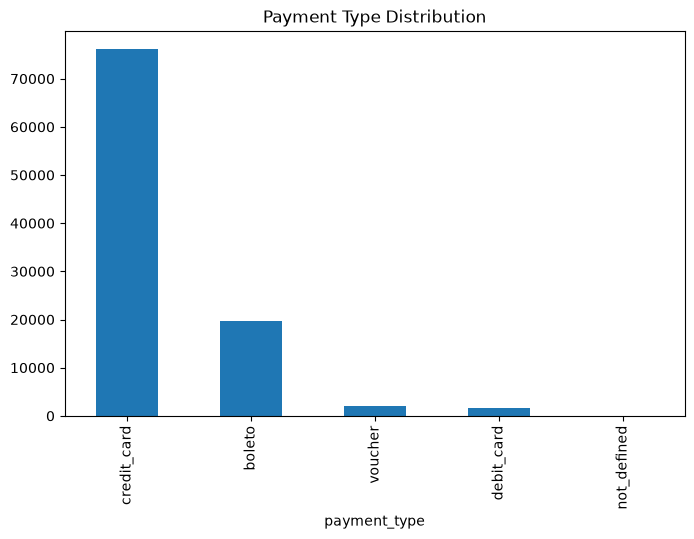

In [21]:
plt.figure(figsize=(8,5))

abt["payment_type"].value_counts().plot(
    kind="bar"
)

plt.title("Payment Type Distribution")

plt.savefig(
    FIGURES_DIR / "payment_type_distribution.png"
)

plt.show()

In [22]:
print(abt.info())

abt.head()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
 8   purchase_year                  99441 non-null  int32         
 9   purchase_month                 99441 non-null  int32         
 10  purchase_day                   99441 non-null  int32         
 11  purchase_dayofweek        

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,purchase_day,purchase_dayofweek,delivery_days,delivery_delay,is_late_delivery,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment,max_installments,payment_type,review_score,has_review_comment,total_price,total_freight,total_items,unique_products,unique_sellers
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2,Monday,8.0,-8.0,0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,1.0,voucher,4.0,1.0,29.99,8.72,1.0,1.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,24,Tuesday,13.0,-6.0,0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1.0,boleto,4.0,1.0,118.70,22.76,1.0,1.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,8,Wednesday,9.0,-18.0,0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,3.0,credit_card,5.0,0.0,159.90,19.22,1.0,1.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,18,Saturday,13.0,-13.0,0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,1.0,credit_card,5.0,1.0,45.00,27.20,1.0,1.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,13,Tuesday,2.0,-10.0,0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,1.0,credit_card,5.0,0.0,19.90,8.72,1.0,1.0,1.0


In [23]:
summary = pd.DataFrame({
    "Rows":[abt.shape[0]],
    "Columns":[abt.shape[1]],
    "Missing Values":[abt.isnull().sum().sum()],
    "Duplicate Rows":[abt.duplicated().sum()]
})

summary.to_csv(
    "../reports/lab02_abt_summary.csv",
    index=False
)

summary

,Rows,Columns,Missing Values,Duplicate Rows
0,99441,29,16252,0
